In [41]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Data Load
df = pd.read_excel("C:/Users/HP/Downloads/Dataset for Data Analytics.xlsx")
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [9]:
# Null Checking
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [14]:
# Null Handling
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [16]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [21]:
# Buisenss Kpi
total_sales = df['TotalPrice'].sum()
total_orders = df['OrderID'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = df['TotalPrice'].mean()
print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("AOV:",avg_order_value)


Total Sales: 1264761.96
Total Orders: 1200
Total Customers: 1189
AOV: 1053.9683


Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


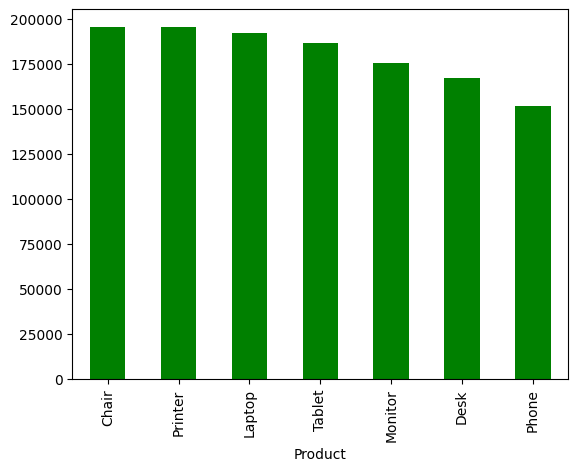

In [24]:
# Top Revenue Product
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
product_sales.plot(kind="bar",color='green')
print(product_sales)

<Axes: ylabel='count'>

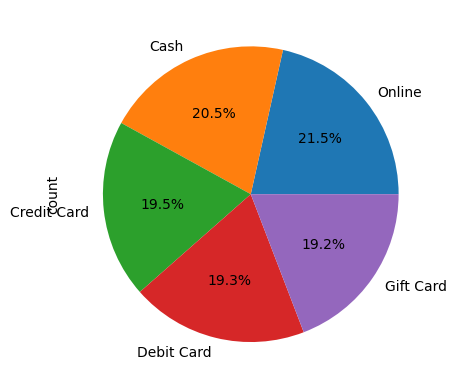

In [28]:
# Payment Method Analysis
df['PaymentMethod'].value_counts().plot(kind='pie',autopct="%1.1f%%")


CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
C16775    3353.75
C65986    3352.40
C47778    3334.00
C59183    3322.55
C25276    3313.90
Name: TotalPrice, dtype: float64


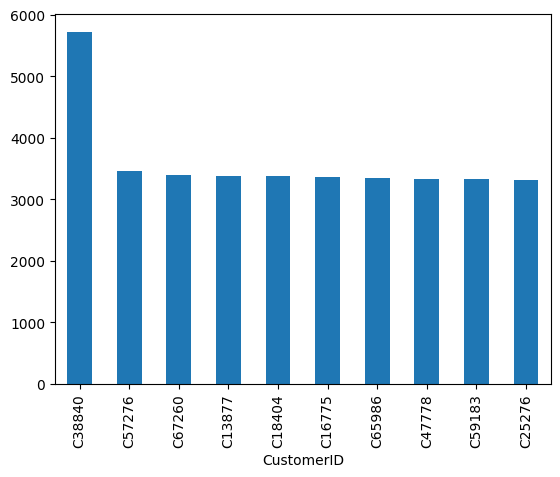

In [36]:
# Top Customer By Sales
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="bar")
print(top_customers)

<Axes: ylabel='count'>

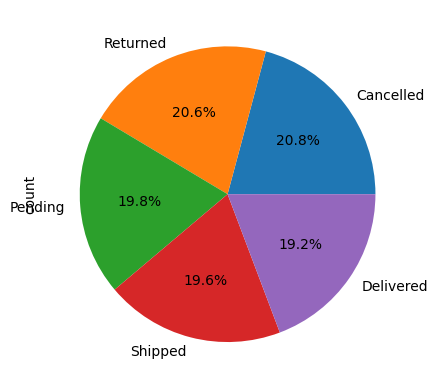

In [29]:
# Order Status
df['OrderStatus'].value_counts().plot(kind='pie',autopct="%1.1f%%")


Date
2023-01-01    2021.11
2023-01-02    1323.55
2023-01-03     897.70
2023-01-04    3629.54
2023-01-05    3642.30
               ...   
2025-06-24    6358.22
2025-06-25     391.83
2025-06-27    1764.15
2025-06-28    3894.68
2025-06-30     505.47
Name: TotalPrice, Length: 671, dtype: float64


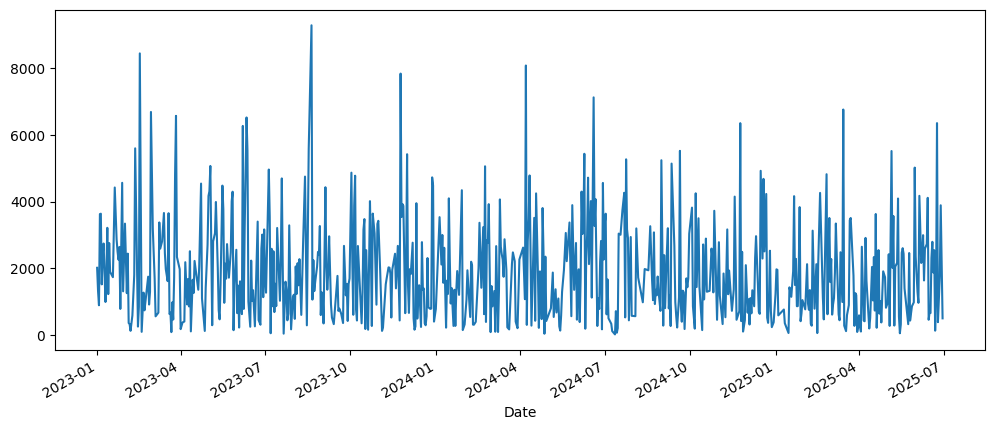

In [35]:
# Monthly Sales Trend
monthly_sales = df.groupby('Date')['TotalPrice'].sum()
monthly_sales.plot(figsize=(12,5))
print(monthly_sales)

In [38]:
# Yearly Revenue
df["Year"] = df['Date'].dt.year
df.groupby("Year")["TotalPrice"].sum()

Year
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64

In [40]:
# Revenue By Order Status
df.groupby("OrderStatus")["TotalPrice"].sum()

OrderStatus
Cancelled    276396.21
Delivered    242600.32
Pending      256328.15
Returned     243277.70
Shipped      246159.58
Name: TotalPrice, dtype: float64

<Axes: xlabel='CouponCode', ylabel='TotalPrice'>

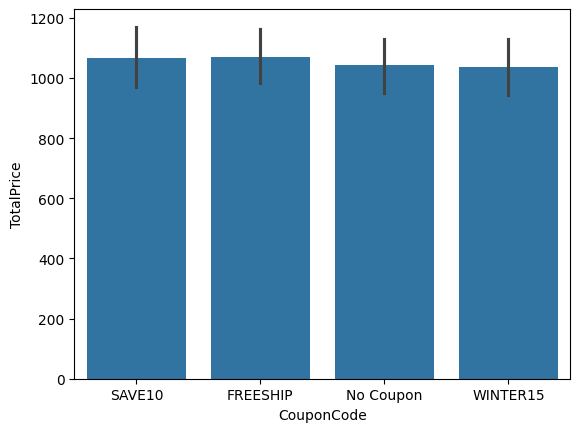

In [42]:
# Coupon Analysis
sns.barplot(
    data=df,
    x="CouponCode",
    y="TotalPrice"
) 